# Dataset Exploration and Initial Audio Analysis

## Introduction

Before building Machine Learning and Deep Learning models for music genre classification, it is important to understand the structure and properties of the datasets used in the project.

This notebook focuses on the initial exploration of the selected datasets:
- GTZAN Dataset
- FMA Dataset (FMA Medium)

The goal is to inspect:
- dataset organization,
- genre distribution,
- audio file properties,
- metadata structure,
- and basic audio signal representations.

In addition, several Digital Signal Processing (DSP) techniques are introduced in order to visualize and better understand the audio data before feature extraction and model training.

---

# Libraries and Dependencies

The following libraries are used in this notebook:

- `pandas` for metadata analysis
- `matplotlib` for visualizations
- `librosa` for audio loading and DSP operations
- `pathlib` and `os` for file system operations

These libraries provide the foundation for audio preprocessing and exploratory data analysis throughout the project.

---

# Dataset Paths and Initialization

The first step is to define the locations of the datasets and verify that all required files and directories are available.

The project uses:
- GTZAN for initial baseline experiments
- FMA Medium for scalability and generalization experiments

The FMA dataset also includes additional metadata files such as:
- `tracks.csv`
- `genres.csv`

which contain genre labels and track information.

---

# GTZAN Dataset Exploration

The GTZAN dataset is organized into folders corresponding to different music genres.

Each genre contains multiple `.au` audio files.

The notebook extracts:
- the list of available genres,
- the number of audio files per genre,
- and visualizes the genre distribution.

This step helps verify:
- dataset balance,
- class consistency,
- and data availability.

Balanced datasets are important for fair model training and evaluation.

---

# Audio Signal Inspection

A sample audio file is loaded using `librosa`.

Several important audio properties are inspected:
- sample rate,
- signal shape,
- audio duration.

Understanding these properties is important because neural networks require consistent and standardized input dimensions.

---

# Waveform Visualization

The waveform represents the audio signal in the time domain.

It shows:
- signal amplitude,
- temporal structure,
- loudness variations over time.

Waveform analysis provides intuition about the structure of music signals before transforming them into frequency-domain representations.

---

# Mel Spectrogram Visualization

The Mel Spectrogram is one of the most important representations used in modern audio classification systems.

It converts the audio signal from:
- the time domain
to:
- a time-frequency representation.

The Mel scale approximates human auditory perception by emphasizing frequencies similarly to how humans hear sound.

Mel Spectrograms are especially useful because they:
- preserve temporal information,
- preserve frequency information,
- and can be treated similarly to images when used with CNN architectures.

---

# MFCC Feature Visualization

MFCCs (Mel-Frequency Cepstral Coefficients) are compact audio descriptors commonly used in:
- speech recognition,
- music information retrieval,
- and audio classification.

MFCC extraction combines:
- Fourier Transform,
- Mel scaling,
- logarithmic compression,
- and cepstral analysis.

These features capture important spectral characteristics of audio signals while reducing dimensionality.

MFCCs will later be used as inputs for:
- classical Machine Learning models,
- and baseline Deep Learning experiments.

---

# FMA Metadata Exploration

Unlike GTZAN, the FMA dataset is metadata-driven.

Genre labels are not encoded directly in folder names. Instead, they are stored inside metadata files such as `tracks.csv`.

The notebook explores:
- available metadata fields,
- subset information,
- genre labels,
- and track organization.

This step demonstrates the importance of metadata processing in real-world Machine Learning pipelines.

---

# Conclusion

This notebook establishes the foundation for the rest of the project.

The performed exploration helps:
- verify dataset integrity,
- understand audio signal structure,
- inspect genre distributions,
- and introduce the DSP concepts required for later feature extraction and model training.

The next steps of the project will focus on:
- audio preprocessing,
- MFCC extraction,
- Mel Spectrogram generation,
- and preparation of inputs for Machine Learning and Deep Learning models.

In [1]:
from pathlib import Path
import os

import pandas as pd
import numpy as np

import librosa
import librosa.display

import matplotlib.pyplot as plt

In [2]:
# plotting style
plt.style.use("ggplot")

# ================================
# Dataset Paths
# ================================

PROJECT_ROOT = Path("..")

GTZAN_PATH = PROJECT_ROOT / "data" / "raw" / "gtzan" / "genres"

FMA_AUDIO_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "fma_medium"
)

FMA_METADATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "fma_metadata"
)

# ================================
# Verify Dataset Paths
# ================================

print("GTZAN exists:", GTZAN_PATH.exists())
print("FMA audio exists:", FMA_AUDIO_PATH.exists())
print("FMA metadata exists:", FMA_METADATA_PATH.exists())

GTZAN exists: True
FMA audio exists: True
FMA metadata exists: True


# GTZAN Dataset Exploration

In [3]:
# ================================
# GTZAN Genre Exploration
# ================================

gtzan_genres = sorted(
    [
        folder.name
        for folder in GTZAN_PATH.iterdir()
        if folder.is_dir()
    ]
)

print("Available genres:")
print(gtzan_genres)

Available genres:
['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [4]:
# ================================
# Count Audio Files per Genre
# ================================

gtzan_counts = {}

for genre in gtzan_genres:
    
    genre_path = GTZAN_PATH / genre
    
    audio_files = list(genre_path.glob("*.au"))
    
    gtzan_counts[genre] = len(audio_files)

genre_distribution = pd.Series(gtzan_counts)

genre_distribution

blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
dtype: int64

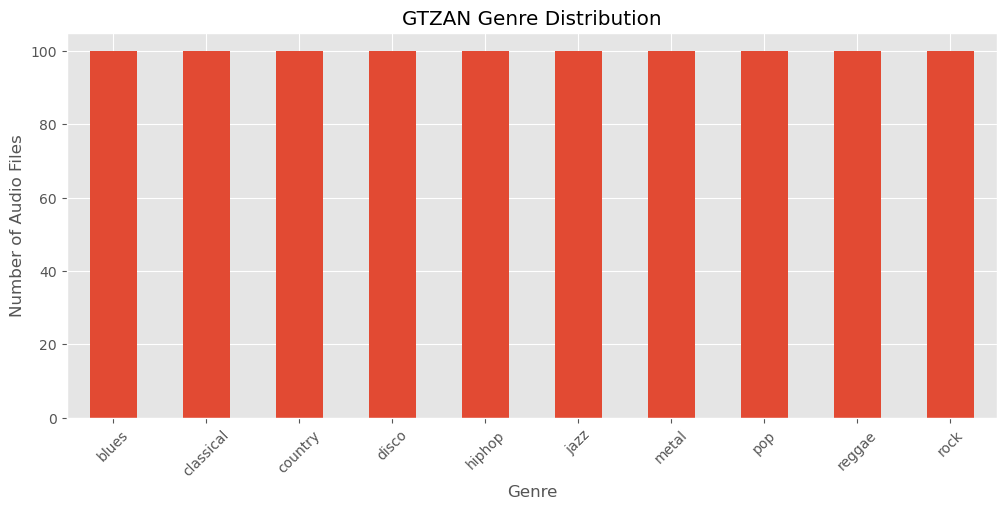

In [5]:
# ================================
# Genre Distribution Visualization
# ================================

plt.figure(figsize=(12, 5))

genre_distribution.sort_index().plot(kind="bar")

plt.title("GTZAN Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Number of Audio Files")

plt.xticks(rotation=45)

plt.show()

In [6]:
# ================================
# Load Example Audio File
# ================================

sample_file = next((GTZAN_PATH / "rock").glob("*.au"))

print("Sample file:")
print(sample_file)

Sample file:
..\data\raw\gtzan\genres\rock\rock.00000.au


In [7]:
# ================================
# Audio Signal Inspection
# ================================

y, sr = librosa.load(sample_file, sr=None)

print("Sample Rate:", sr)
print("Signal Shape:", y.shape)

duration = librosa.get_duration(y=y, sr=sr)

print("Duration:", duration, "seconds")

Sample Rate: 22050
Signal Shape: (661794,)
Duration: 30.013333333333332 seconds


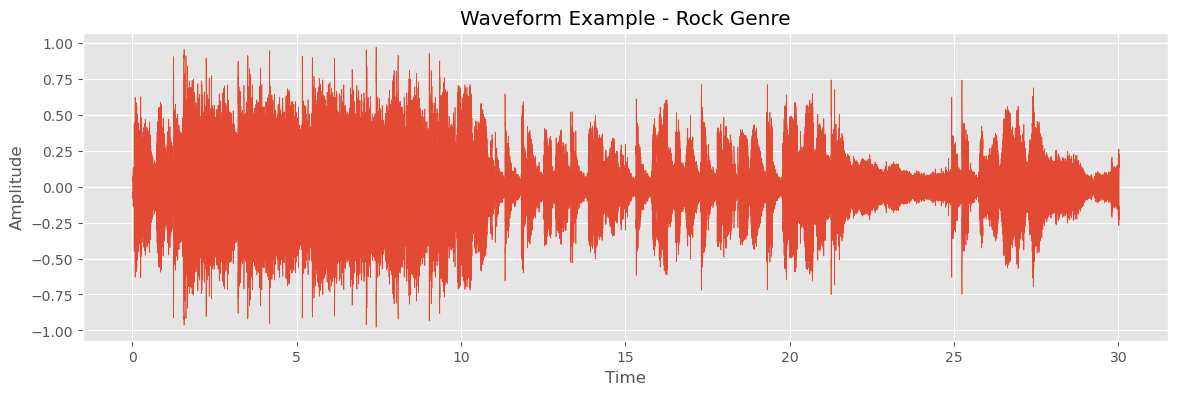

In [8]:
# ================================
# Waveform Visualization
# ================================

plt.figure(figsize=(14, 4))

librosa.display.waveshow(y, sr=sr)

plt.title("Waveform Example - Rock Genre")

plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

In [9]:
# ================================
# Dataset Statistics
# ================================

sample_lengths = []

for genre in gtzan_genres:

    files = list((GTZAN_PATH / genre).glob("*.au"))

    for file in files[:10]:

        y_tmp, sr_tmp = librosa.load(file, sr=None)

        sample_lengths.append(
            librosa.get_duration(
                y=y_tmp,
                sr=sr_tmp
            )
        )

print("Average duration:", np.mean(sample_lengths))
print("Min duration:", np.min(sample_lengths))
print("Max duration:", np.max(sample_lengths))

Average duration: 30.03039818594104
Min duration: 29.98185941043084
Max duration: 30.370975056689343


# Dataset Statistics

In addition to genre distribution, basic audio statistics are explored.

The duration of the audio files is inspected to verify consistency across the dataset.

Uniform sample duration simplifies preprocessing and allows the use of fixed-size neural network inputs.

In [10]:
# ================================
# Audio Summary Table
# ================================

audio_summary = pd.DataFrame({

    "Sample Rate": [sr],
    "Duration (s)": [duration],
    "Samples": [len(y)]

})

audio_summary

,Sample Rate,Duration (s),Samples
0,22050,30.013333,661794


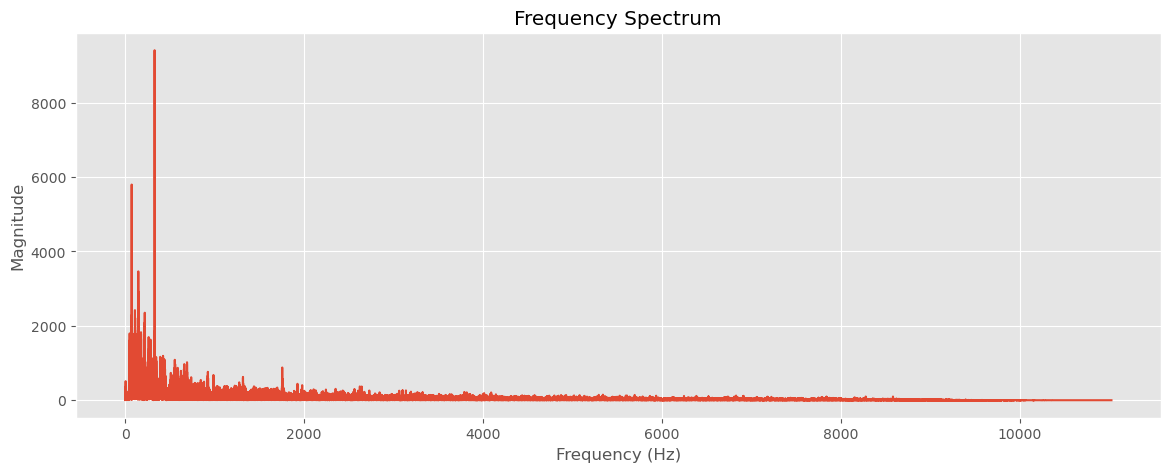

In [11]:
# ================================
# Frequency Spectrum
# ================================

fft = np.abs(
    np.fft.rfft(y)
)

freq = np.fft.rfftfreq(
    len(y),
    1 / sr
)

plt.figure(figsize=(14,5))

plt.plot(
    freq,
    fft
)

plt.title(
    "Frequency Spectrum"
)

plt.xlabel(
    "Frequency (Hz)"
)

plt.ylabel(
    "Magnitude"
)

plt.show()

# Frequency Domain Representation

The Fourier Transform converts an audio signal from the time domain into the frequency domain.

Instead of observing how amplitude changes over time, the signal is decomposed into individual frequency components and their corresponding magnitudes.

The generated spectrum shows how acoustic energy is distributed across different frequencies.

Several observations can be made:

- Most of the signal energy appears concentrated in lower frequency regions.
- Higher frequencies contain less overall energy.
- Multiple peaks indicate dominant harmonic components and musical content.

Frequency-domain analysis is fundamental for Digital Signal Processing (DSP) because it serves as the mathematical foundation for:

- Short-Time Fourier Transform (STFT)
- Spectrogram generation
- Mel Spectrogram extraction
- MFCC computation

Understanding frequency decomposition helps explain why neural networks can later learn genre-specific spectral patterns from audio representations.

Observation:

The selected audio sample exhibits strong low-frequency content with gradually decreasing energy at higher frequencies, which is characteristic of many musical recordings and motivates the use of frequency-based representations for classification tasks.

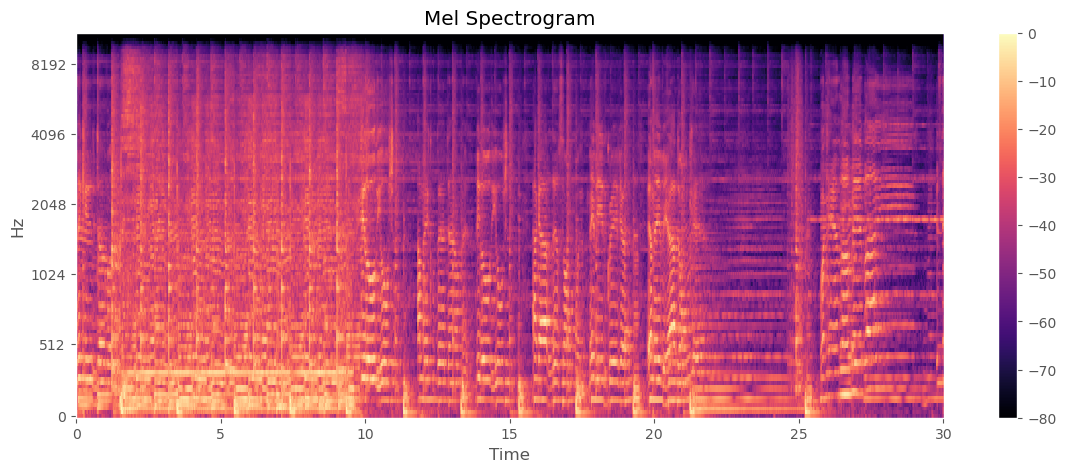

In [12]:
# ================================
# Mel Spectrogram
# ================================

mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

plt.figure(figsize=(14,5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title(
    "Mel Spectrogram"
)

plt.show()

# Mel Spectrogram Analysis

The Mel Spectrogram transforms the audio signal into a time-frequency representation while approximating human auditory perception.

Unlike the waveform, which shows amplitude over time, the spectrogram reveals how energy is distributed across frequencies throughout the recording.

Several observations can be made:

- Lower frequencies contain most of the acoustic energy.
- Energy distribution changes continuously over time.
- Distinct vertical and horizontal patterns suggest changes in rhythm, harmonics, and instrumentation.

Mel Spectrograms preserve both temporal and spectral information, which makes them highly suitable for Convolutional Neural Networks (CNNs).

For this reason, Mel Spectrogram representations will later be used as inputs for Deep Learning models in this project.

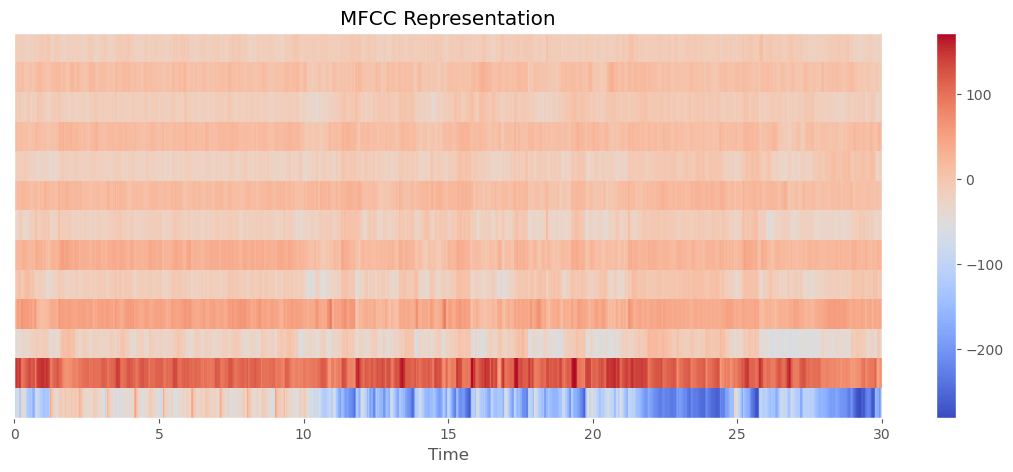

In [13]:
# ================================
# MFCC Visualization
# ================================

mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=13
)

plt.figure(figsize=(14,5))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr
)

plt.colorbar()

plt.title(
    "MFCC Representation"
)

plt.show()

# MFCC Feature Analysis

MFCC (Mel-Frequency Cepstral Coefficients) provides a compressed representation of the spectral characteristics of the audio signal.

Unlike Mel Spectrograms, MFCC reduces dimensionality by summarizing frequency information into a smaller number of coefficients.

Several observations can be made:

- The first coefficients contain most of the overall signal energy.
- Higher-order coefficients capture finer spectral variations.
- Temporal changes remain visible while significantly reducing feature dimensionality.

MFCC features are widely used in:

- speech recognition,
- music information retrieval,
- audio classification.

Because of their compact representation, MFCC features will later be evaluated using both classical Machine Learning and baseline Deep Learning approaches.

# Comparison of Audio Representations

Although both representations originate from the same audio signal, they preserve different information.

| Representation | Advantages | Typical Usage |
|---|---|---|
| Mel Spectrogram | Rich time-frequency information | CNN / Deep Learning |
| MFCC | Compact and computationally efficient | Classical Machine Learning |

This project later compares both representations experimentally in order to evaluate their impact on classification performance, model complexity, and generalization.

# FMA Metadata Exploration

In [14]:
# ================================
# Load FMA Metadata
# ================================

tracks_path = (
    FMA_METADATA_PATH
    / "tracks.csv"
)

tracks = pd.read_csv(
    tracks_path,
    header=[0, 1],
    index_col=0
)

print(
    "Tracks loaded successfully."
)

tracks.head()

Tracks loaded successfully.


album                                                     \
         comments         date_created        date_released engineer   
track_id                                                               
2               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
3               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
5               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
10              0  2008-11-26 01:45:08  2008-02-06 00:00:00      NaN   
20              0  2008-11-26 01:45:05  2009-01-06 00:00:00      NaN   

                                                                          \
         favorites id                                information listens   
track_id                                                                   
2                4  1                                    <p></p>    6073   
3                4  1                                    <p></p>    6073   
5                4  1                                    <p></p>    6073   
10               4  6                                        NaN   47632   
20               2  4  <p> "spiritual songs" from Nicky Cook</p>    2710   

                        ...       track                         \
         producer tags  ... information interest language_code   
track_id                ...                                      
2             NaN   []  ...         NaN     4656            en   
3             NaN   []  ...         NaN     1470            en   
5             NaN   []  ...         NaN     1933            en   
10            NaN   []  ...         NaN    54881            en   
20            NaN   []  ...         NaN      978            en   

                                                                              \
                                                    license listens lyricist   
track_id                                                                       
2         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1293      NaN   
3         Attribution-NonCommercial-ShareAlike 3.0 Inter...     514      NaN   
5         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1151      NaN   
10        Attribution-NonCommercial-NoDerivatives (aka M...   50135      NaN   
20        Attribution-NonCommercial-NoDerivatives (aka M...     361      NaN   

                                                 
         number publisher tags            title  
track_id                                         
2             3       NaN   []             Food  
3             4       NaN   []     Electric Ave  
5             6       NaN   []       This World  
10            1       NaN   []          Freeway  
20            3       NaN   []  Spiritual Level  

[5 rows x 52 columns]

In [15]:
# ================================
# Metadata Structure
# ================================

tracks.columns

MultiIndex([( 'album',          'comments'),
            ( 'album',      'date_created'),
            ( 'album',     'date_released'),
            ( 'album',          'engineer'),
            ( 'album',         'favorites'),
            ( 'album',                'id'),
            ( 'album',       'information'),
            ( 'album',           'listens'),
            ( 'album',          'producer'),
            ( 'album',              'tags'),
            ( 'album',             'title'),
            ( 'album',            'tracks'),
            ( 'album',              'type'),
            ('artist', 'active_year_begin'),
            ('artist',   'active_year_end'),
            ('artist', 'associated_labels'),
            ('artist',               'bio'),
            ('artist',          'comments'),
            ('artist',      'date_created'),
            ('artist',         'favorites'),
            ('artist',                'id'),
            ('artist',          'latitude'),
          

In [16]:
# ================================
# FMA Dataset Subsets
# ================================

subset_distribution = (
    tracks[
        ("set","subset")
    ]
    .value_counts()
)

subset_distribution

(set, subset)
large     81574
medium    17000
small      8000
Name: count, dtype: int64

In [17]:
# ================================
# Select FMA Medium
# ================================


fma_medium = tracks[
    tracks[
        ("set","subset")
    ] == "medium"
]

genre_distribution = (
    fma_medium[
        ("track","genre_top")
    ]
    .value_counts()
)

genre_distribution

(track, genre_top)
Rock                   6103
Electronic             5314
Experimental           1251
Hip-Hop                1201
Classical               619
Folk                    519
Old-Time / Historic     510
Jazz                    384
Instrumental            350
Pop                     186
Country                 178
Soul-RnB                154
Spoken                  118
Blues                    74
Easy Listening           21
International            18
Name: count, dtype: int64

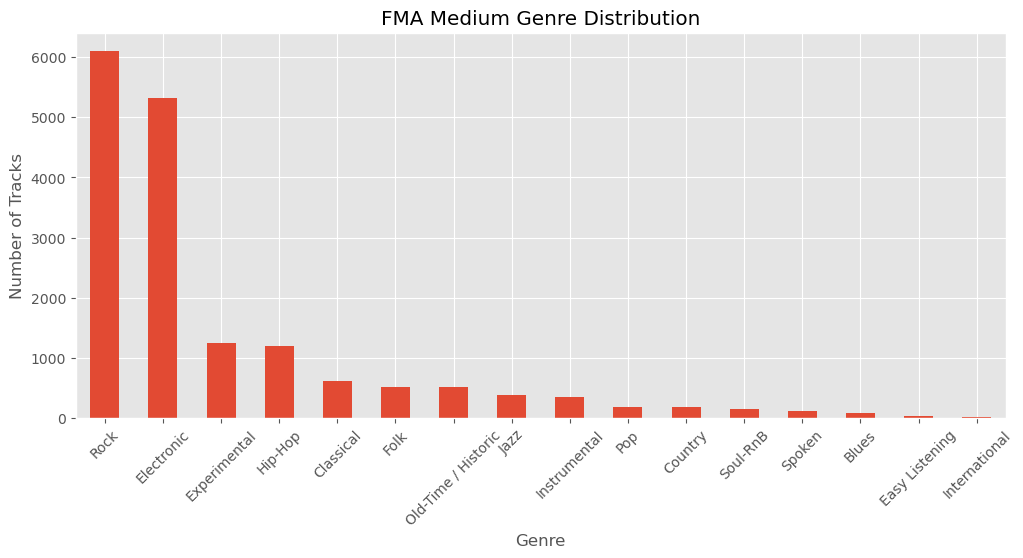

In [18]:
# ================================
# FMA Genre Visualization
# ================================

plt.figure(
    figsize=(12,5)
)

genre_distribution.plot(
    kind="bar"
)

plt.title(
    "FMA Medium Genre Distribution"
)

plt.xlabel(
    "Genre"
)

plt.ylabel(
    "Number of Tracks"
)

plt.xticks(
    rotation=45
)

plt.show()

In [19]:
# ================================
# FMA Duration Statistics
# ================================

durations = (
    fma_medium[
        ("track", "duration")
    ]
)

print(
    durations.describe()
)

count    17000.000000
mean       230.409824
std        103.986197
min         60.000000
25%        156.000000
50%        213.000000
75%        285.000000
max        600.000000
Name: (track, duration), dtype: float64


In [20]:
# ================================
# Compare Dataset Durations
# ================================

gtzan_duration = np.mean(
    sample_lengths
)

comparison = pd.DataFrame({

    "Dataset":[
        "GTZAN",
        "FMA Medium"
    ],

    "Average Duration (s)":[
        gtzan_duration,
        durations.mean()
    ]

})

comparison

,Dataset,Average Duration (s)
0,GTZAN,30.030398
1,FMA Medium,230.409824


# Dataset Duration Comparison

A comparison between GTZAN and FMA Medium reveals a significant difference in recording duration.

GTZAN contains short and standardized excerpts, while FMA Medium includes substantially longer recordings.

This observation motivates the need for duration normalization during preprocessing.

Audio standardization will be introduced in the next notebook before extracting MFCC and Mel Spectrogram features.

Possible preprocessing strategies include:

- fixed-length cropping,
- center cropping,
- random cropping,
- segmentation into shorter windows.

For consistency across experiments, identical preprocessing settings will later be applied before generating MFCC and Mel Spectrogram representations.

In [21]:
print("Total tracks:", tracks.shape)

print("FMA Medium shape:")

print(fma_medium.shape)

print(
    "Missing top genres:",
    fma_medium[
        ("track","genre_top")
    ].isna().sum()
)

Total tracks: (106574, 52)
FMA Medium shape:
(17000, 52)
Missing top genres: 0


In [22]:
# Shared Genres with GTZAN

gtzan_set = {
    g.lower()
    for g in gtzan_genres
}

fma_set = {
    g
    for g in fma_medium[
        ("track","genre_top")
    ].dropna().unique()
}

shared = []

for genre in fma_set:

    if genre.lower().replace(
        "-",
        ""
    ) in gtzan_set:

        shared.append(
            genre
        )

print(
    "Shared genres:"
)

print(
    sorted(shared)
)

Shared genres:
['Blues', 'Classical', 'Country', 'Hip-Hop', 'Jazz', 'Pop', 'Rock']


# External Evaluation Strategy

The FMA Medium dataset will be used exclusively for final external evaluation.

Because GTZAN and FMA Medium contain different genre taxonomies, only overlapping genres are selected for comparison.

The selected shared genres are:

- Blues
- Classical
- Country
- Hip-Hop
- Jazz
- Pop
- Rock

The external evaluation dataset remains naturally imbalanced in order to better simulate real-world music collections.

Therefore, performance will not be measured using accuracy alone.

The following evaluation metrics will be reported:

- Accuracy
- Precision
- Recall
- Macro F1 Score
- Weighted F1 Score
- Confusion Matrix

Macro-averaged metrics are included because they assign equal importance to each genre regardless of class frequency.

No FMA samples are used during training or validation.

# Conclusion

This notebook establishes the foundation for the rest of the project.

The performed exploration helped to:

- verify dataset integrity,
- inspect dataset organization,
- understand audio signal structure,
- analyze genre distributions,
- visualize waveform, frequency-domain, Mel Spectrogram, and MFCC representations,
- and introduce the DSP concepts required for later feature extraction and model training.

In addition, an external evaluation strategy was defined.

GTZAN will be used for:
- training,
- validation,
- and model development.

FMA Medium will be used only for final external evaluation.

Because both datasets contain different genre taxonomies, only the following shared genres will be evaluated:

- Blues
- Classical
- Country
- Hip-Hop
- Jazz
- Pop
- Rock

The external evaluation remains naturally imbalanced in order to simulate realistic music distributions.

An additional observation is that FMA Medium contains substantially longer recordings than GTZAN, which motivates the introduction of standardized preprocessing in the next notebook.

The next steps of the project will focus on:

- audio preprocessing,
- dataset preparation,
- feature extraction,
- MFCC generation,
- Mel Spectrogram generation,
- preparation of inputs for Machine Learning models,
- and baseline Deep Learning experiments.

